# Предобработка данных: пропуски, категориальные признаки, масштабирование

Лабораторная работа №2.

## 1) Описание набора данных

Используется датасет **Titanic** — информация о пассажирах «Титаника» (функция `seaborn.load_dataset('titanic')`).

- Документация Seaborn: https://seaborn.pydata.org/generated/seaborn.load_dataset.html
- Исходное описание: https://www.kaggle.com/c/titanic/data

Набор содержит **891 запись** и **15 признаков**:

| Признак | Описание |
|---------|----------|
| `survived` | Выжил ли пассажир (0/1) — целевая переменная |
| `pclass` | Класс билета (1, 2, 3) |
| `sex` | Пол |
| `age` | Возраст |
| `sibsp` | Число братьев/сестёр и супругов на борту |
| `parch` | Число родителей/детей на борту |
| `fare` | Стоимость билета |
| `embarked` | Порт посадки (C, Q, S) |
| `class` | Класс билета (категориальный) |
| `who` | Категория: man / woman / child |
| `deck` | Палуба (много пропусков) |
| `embark_town` | Город посадки |
| `alive` | yes / no |
| `alone` | Путешествовал один |

Датасет подходит для лабораторной: есть **категориальные признаки** (`sex`, `embarked`, `class`, …) и **пропуски** (в `age`, `deck`, `embarked`).
Размер небольшой, данные загружаются без дополнительной подготовки.

## Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

%matplotlib inline
sns.set(style="ticks")

## Загрузка и первичный осмотр данных

In [ ]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
print(f"Размерность: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nТипы данных:")
print(df.dtypes)
print("\nОписательная статистика (числовые признаки):")
df.describe()

Размерность: 891 строк, 15 столбцов

Типы данных:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Описательная статистика (числовые признаки):


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({'пропусков': missing, 'доля, %': missing_pct})
missing_table[missing_table['пропусков'] > 0].sort_values('пропусков', ascending=False)

,пропусков,"доля, %"
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


## 2) Обработка пропусков в данных

Стратегия обработки пропусков (по материалам лекции):

1. **Удаление признаков** с слишком большой долей пропусков (`deck` — ~77%), если они не несут достаточно информации.
2. **Импутация числовых признаков** — медиана (устойчива к выбросам); для `age` используем медиану внутри групп `sex` × `pclass`.
3. **Импутация категориальных признаков** — наиболее частое значение (мода).
4. **Удаление дублирующих столбцов** (`class` дублирует `pclass`, `alive` — `survived`, `embark_town` — `embarked`).

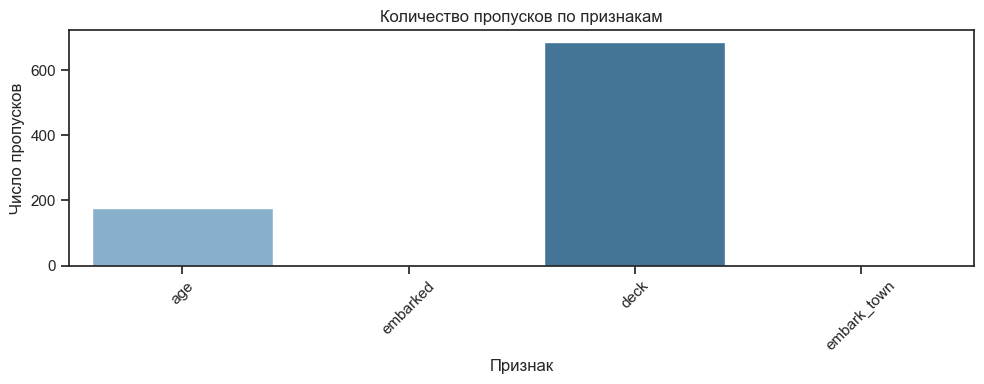

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_na = (
    missing_table[missing_table['пропусков'] > 0]
    .reset_index(names='признак')
)
sns.barplot(
    data=plot_na,
    x='признак',
    y='пропусков',
    hue='признак',
    palette='Blues_d',
    legend=False,
    ax=ax,
)
ax.set_title('Количество пропусков по признакам')
ax.set_ylabel('Число пропусков')
ax.set_xlabel('Признак')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_clean = df.drop(columns=['deck', 'class', 'alive', 'embark_town', 'who', 'adult_male'])

# Медианная импутация age по группам sex + pclass
df_clean['age'] = df_clean.groupby(['sex', 'pclass'])['age'].transform(
    lambda s: s.fillna(s.median())
)
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Мода для embarked
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

print('Пропуски после обработки:')
print(df_clean.isna().sum())
df_clean.head()

Пропуски после обработки:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [ ]:
# Альтернатива через sklearn SimpleImputer (для числовых и категориальных столбцов)
numeric_cols = ['age', 'sibsp', 'parch', 'fare']
cat_cols = ['sex', 'embarked']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df_sklearn = df_clean.copy()
df_sklearn[numeric_cols] = num_imputer.fit_transform(df_sklearn[numeric_cols])
df_sklearn[cat_cols] = cat_imputer.fit_transform(df_sklearn[cat_cols])

print('SimpleImputer — пропусков:', df_sklearn.isna().sum().sum())

SimpleImputer — пропусков: 0


## 3) Кодирование категориальных признаков

Для категориальных признаков применяются два основных подхода:

- **Label Encoding** — каждой категории присваивается целое число. Подходит для **ordinal** признаков (упорядоченных), например `pclass`.
- **One-Hot Encoding** — для каждой категории создаётся отдельный бинарный столбец. Подходит для **nominal** признаков без порядка (`sex`, `embarked`).

In [ ]:
df_encoded = df_sklearn.copy()

# Label Encoding для pclass (ordinal: 1 > 2 > 3 по «качеству» класса)
le_pclass = LabelEncoder()
df_encoded['pclass_le'] = le_pclass.fit_transform(df_encoded['pclass'].astype(str))
print('Label Encoding pclass:', dict(zip(le_pclass.classes_, le_pclass.transform(le_pclass.classes_))))

# Label Encoding для sex (бинарный признак)
le_sex = LabelEncoder()
df_encoded['sex_le'] = le_sex.fit_transform(df_encoded['sex'])
print('Label Encoding sex:', dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))

df_encoded[['pclass', 'pclass_le', 'sex', 'sex_le']].head()

Label Encoding pclass: {'1': np.int64(0), '2': np.int64(1), '3': np.int64(2)}
Label Encoding sex: {'female': np.int64(0), 'male': np.int64(1)}


,pclass,pclass_le,sex,sex_le
0,3,2,male,1
1,1,0,female,0
2,3,2,female,0
3,1,0,female,0
4,3,2,male,1


In [ ]:
# One-Hot Encoding для embarked (nominal, 3 категории)
embarked_ohe = pd.get_dummies(df_encoded['embarked'], prefix='embarked', dtype=int)
df_encoded = pd.concat([df_encoded, embarked_ohe], axis=1)

print('Столбцы после One-Hot для embarked:')
print(embarked_ohe.columns.tolist())
df_encoded[['embarked'] + embarked_ohe.columns.tolist()].head()

Столбцы после One-Hot для embarked:
['embarked_C', 'embarked_Q', 'embarked_S']


,embarked,embarked_C,embarked_Q,embarked_S
0,S,0,0,1
1,C,1,0,0
2,S,0,0,1
3,S,0,0,1
4,S,0,0,1


In [ ]:
# One-Hot через sklearn (удобно в пайплайнах)
ohe = OneHotEncoder(sparse_output=False, drop='first')
embarked_sk = ohe.fit_transform(df_sklearn[['embarked']])
embarked_sk_df = pd.DataFrame(
    embarked_sk,
    columns=ohe.get_feature_names_out(['embarked']),
    index=df_sklearn.index
)
print('OneHotEncoder (drop first):')
embarked_sk_df.head()

OneHotEncoder (drop first):


,embarked_Q,embarked_S
0,0.0,1.0
1,0.0,0.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0


In [ ]:
# Итоговый набор признаков для моделирования
feature_cols = ['pclass_le', 'sex_le', 'age', 'sibsp', 'parch', 'fare', 'alone'] + embarked_ohe.columns.tolist()
X = df_encoded[feature_cols]
y = df_encoded['survived']

print(f'Матрица признаков: {X.shape}')
X.head()

Матрица признаков: (891, 10)


,pclass_le,sex_le,age,sibsp,parch,fare,alone,embarked_C,embarked_Q,embarked_S
0,2,1,22.0,1.0,0.0,7.2500,False,0,0,1
1,0,0,38.0,1.0,0.0,71.2833,False,1,0,0
2,2,0,26.0,0.0,0.0,7.9250,True,0,0,1
3,0,0,35.0,1.0,0.0,53.1000,False,0,0,1
4,2,1,35.0,0.0,0.0,8.0500,True,0,0,1


## 4) Масштабирование данных

Числовые признаки имеют разные диапазоны (`age` ~ 0–80, `fare` до сотен). Для алгоритмов, чувствительных к масштабу (SVM, k-NN, градиентный спуск), применяют **нормализацию**:

- **StandardScaler** — центрирование (вычитание среднего) и деление на стандартное отклонение: \( z = \frac{x - \mu}{\sigma} \).
- **MinMaxScaler** — приведение к диапазону \([0, 1]\): \( x' = \frac{x - x_{min}}{x_{max} - x_{min}} \).

In [ ]:
scale_cols = ['age', 'sibsp', 'parch', 'fare']

print('Статистики ДО масштабирования:')
X[scale_cols].describe().round(2)

Статистики ДО масштабирования:


,age,sibsp,parch,fare
count,891.00,891.00,891.00,891.00
mean,29.11,0.52,0.38,32.20
std,13.30,1.10,0.81,49.69
min,0.42,0.00,0.00,0.00
25%,21.50,0.00,0.00,7.91
50%,26.00,0.00,0.00,14.45
75%,36.00,1.00,0.00,31.00
max,80.00,8.00,6.00,512.33


In [ ]:
scaler_std = StandardScaler()
X_std = X.copy()
X_std[scale_cols] = scaler_std.fit_transform(X[scale_cols])

scaler_mm = MinMaxScaler()
X_mm = X.copy()
X_mm[scale_cols] = scaler_mm.fit_transform(X[scale_cols])

print('StandardScaler — describe:')
display(X_std[scale_cols].describe().round(3))
print('\nMinMaxScaler — describe:')
display(X_mm[scale_cols].describe().round(3))

StandardScaler — describe:


,age,sibsp,parch,fare
count,891.000,891.000,891.000,891.000
mean,0.000,0.000,0.000,0.000
std,1.001,1.001,1.001,1.001
min,-2.158,-0.475,-0.474,-0.648
25%,-0.572,-0.475,-0.474,-0.489
50%,-0.234,-0.475,-0.474,-0.357
75%,0.518,0.433,-0.474,-0.024
max,3.827,6.784,6.974,9.667



MinMaxScaler — describe:


,age,sibsp,parch,fare
count,891.000,891.000,891.000,891.000
mean,0.361,0.065,0.064,0.063
std,0.167,0.138,0.134,0.097
min,0.000,0.000,0.000,0.000
25%,0.265,0.000,0.000,0.015
50%,0.321,0.000,0.000,0.028
75%,0.447,0.125,0.000,0.061
max,1.000,1.000,1.000,1.000


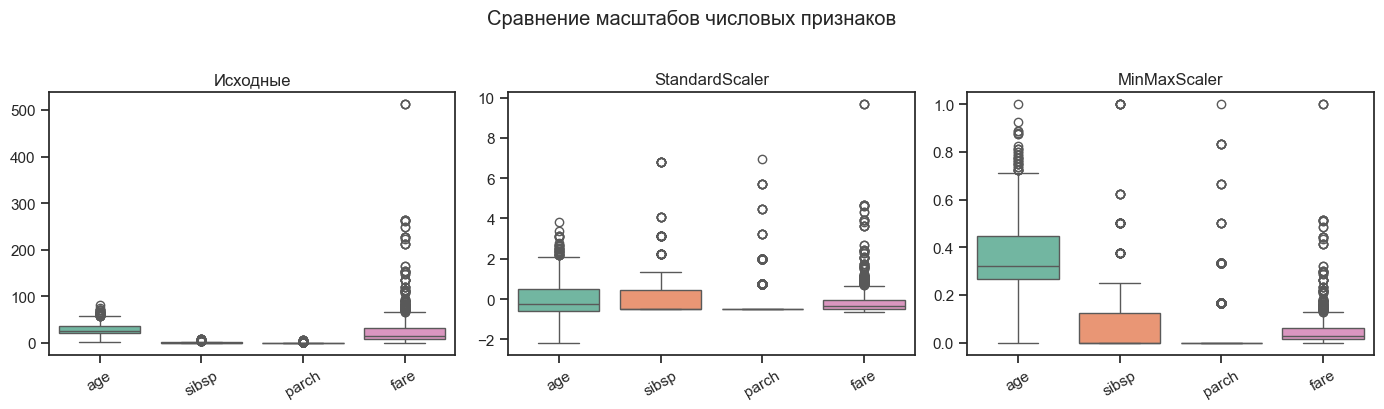

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, title in zip(
    axes,
    [X[scale_cols], X_std[scale_cols], X_mm[scale_cols]],
    ['Исходные', 'StandardScaler', 'MinMaxScaler']
):
    plot_data = data.melt(var_name='признак', value_name='значение')
    sns.boxplot(
        data=plot_data,
        x='признак',
        y='значение',
        hue='признак',
        palette='Set2',
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Сравнение масштабов числовых признаков', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Комбинированный пайплайн: импутация + кодирование + масштабирование
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), ['age', 'sibsp', 'parch', 'fare']),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False)),
        ]), ['sex', 'embarked']),
    ],
    remainder='passthrough'
)

raw_features = df.drop(columns=['survived', 'deck', 'class', 'alive', 'embark_town', 'who', 'adult_male'])
X_pipeline = preprocessor.fit_transform(raw_features)

print(f'Размерность после пайплайна: {X_pipeline.shape}')
print('Первые 5 строк преобразованной матрицы:')
pd.DataFrame(X_pipeline).head()

Размерность после пайплайна: (891, 9)
Первые 5 строк преобразованной матрицы:


,0,1,2,3,4,5,6,7,8
0,-0.565736,0.432793,-0.473674,-0.502445,1.0,0.0,1.0,3,False
1,0.663861,0.432793,-0.473674,0.786845,0.0,0.0,0.0,1,False
2,-0.258337,-0.474545,-0.473674,-0.488854,0.0,0.0,1.0,3,True
3,0.433312,0.432793,-0.473674,0.42073,0.0,0.0,1.0,1,False
4,0.433312,-0.474545,-0.473674,-0.486337,1.0,0.0,1.0,3,True


## Выводы

1. **Пропуски**: в датасете Titanic пропуски сосредоточены в `age`, `deck`, `embarked`. Признак `deck` удалён из-за ~77% пропусков; `age` заполнен медианой по группам, `embarked` — модой.
2. **Категориальные признаки**: для ordinal (`pclass`) применён Label Encoding; для nominal (`sex`, `embarked`) — One-Hot Encoding.
3. **Масштабирование**: StandardScaler приводит признаки к нулевому среднему и единичной дисперсии; MinMaxScaler — к интервалу [0, 1]. Для практики удобно объединять шаги в `Pipeline` / `ColumnTransformer`.